##### Week 5 In-Class Assessment

## Part I: White and Red Noise

This week we will have some fun generating white and red noise wave files. We will discuss the theory of white and red noise in the courseware, but we will get warmed up by playing around with audio file generation.

A red noise process is simply a process that contains ***autocorrelation***. We can, therefore, define a red noise process, $x(t)$ in the following way (we will derive this in lecture):

**Red Noise Equation**

$x(t) = a * x(t - \Delta t) + b * \epsilon (t)$ 

where 

- $a$ lies between 0 and 1 and measures the memory of the previous state

- $\Delta t$ is the time interval between data points (and is assumed to be a constant here)

- $\epsilon (t)$ is a random variable drawn from the standard normal distribution and represents white noise in the system (we will formally define white noise later)

- $b = \sqrt{(1 - a^2)}$

So, note that $x(t)$ depends on $x(t - \Delta t)$, i.e. the present state of $x$ depends on the previous state of $x$ --> **autocorrelation!**

Note, when $a$=0, the red noise process becomes a **white noise**, aka random, process.

Here we will generate four different time series using this definition, with varying values of $a$. 

In [2]:
import numpy as np

# Define the time series length
t = np.arange(0,220500,1.) # time

# Define a vector of autocorrelations, a
auto_vec = np.array([0, .4, .7, .99]) 

# initialize an empty array for x
# x has two dimensions: the first is the length of the time series and 
# the second is the lengthe of a, i.e., we have a time series for each value of a
x = np.empty((np.size(t),len(auto_vec)))

# loop over a
for ia,a in enumerate(auto_vec):

    # define b based on a
    b = np.sqrt(1. - a**2)
    
    # extract an initial (t = 0) random normal value for x
    x[0,ia] = np.random.normal(0.,1.)
    
    # loop over t
    for it,tval in enumerate(t[1:]):
        # generate x as a function of t for each value of a
        # this is equivalent to the red noise equation above
        x[it+1,ia] = a*x[it,ia] + b*np.random.normal(0.,1.) 
       
    # normalize by the largest absolute value
    x[:,ia] = x[:,ia]/np.maximum(np.abs(np.min(x[:,ia])),np.max(x[:,ia])) 

So, $x$ is now an 2-dimenstional array of size:

In [3]:
print(x.shape)

(220500, 4)


where x is a function of time and the four values for a that we defined.

## Plotting noise time series

Now, let's plot these different time series. You should see that the time series look somewhat different.

In [4]:
from matplotlib import pyplot as plt

Text(0.5, 1.0, '(d) Red Noise (a=0.99)')

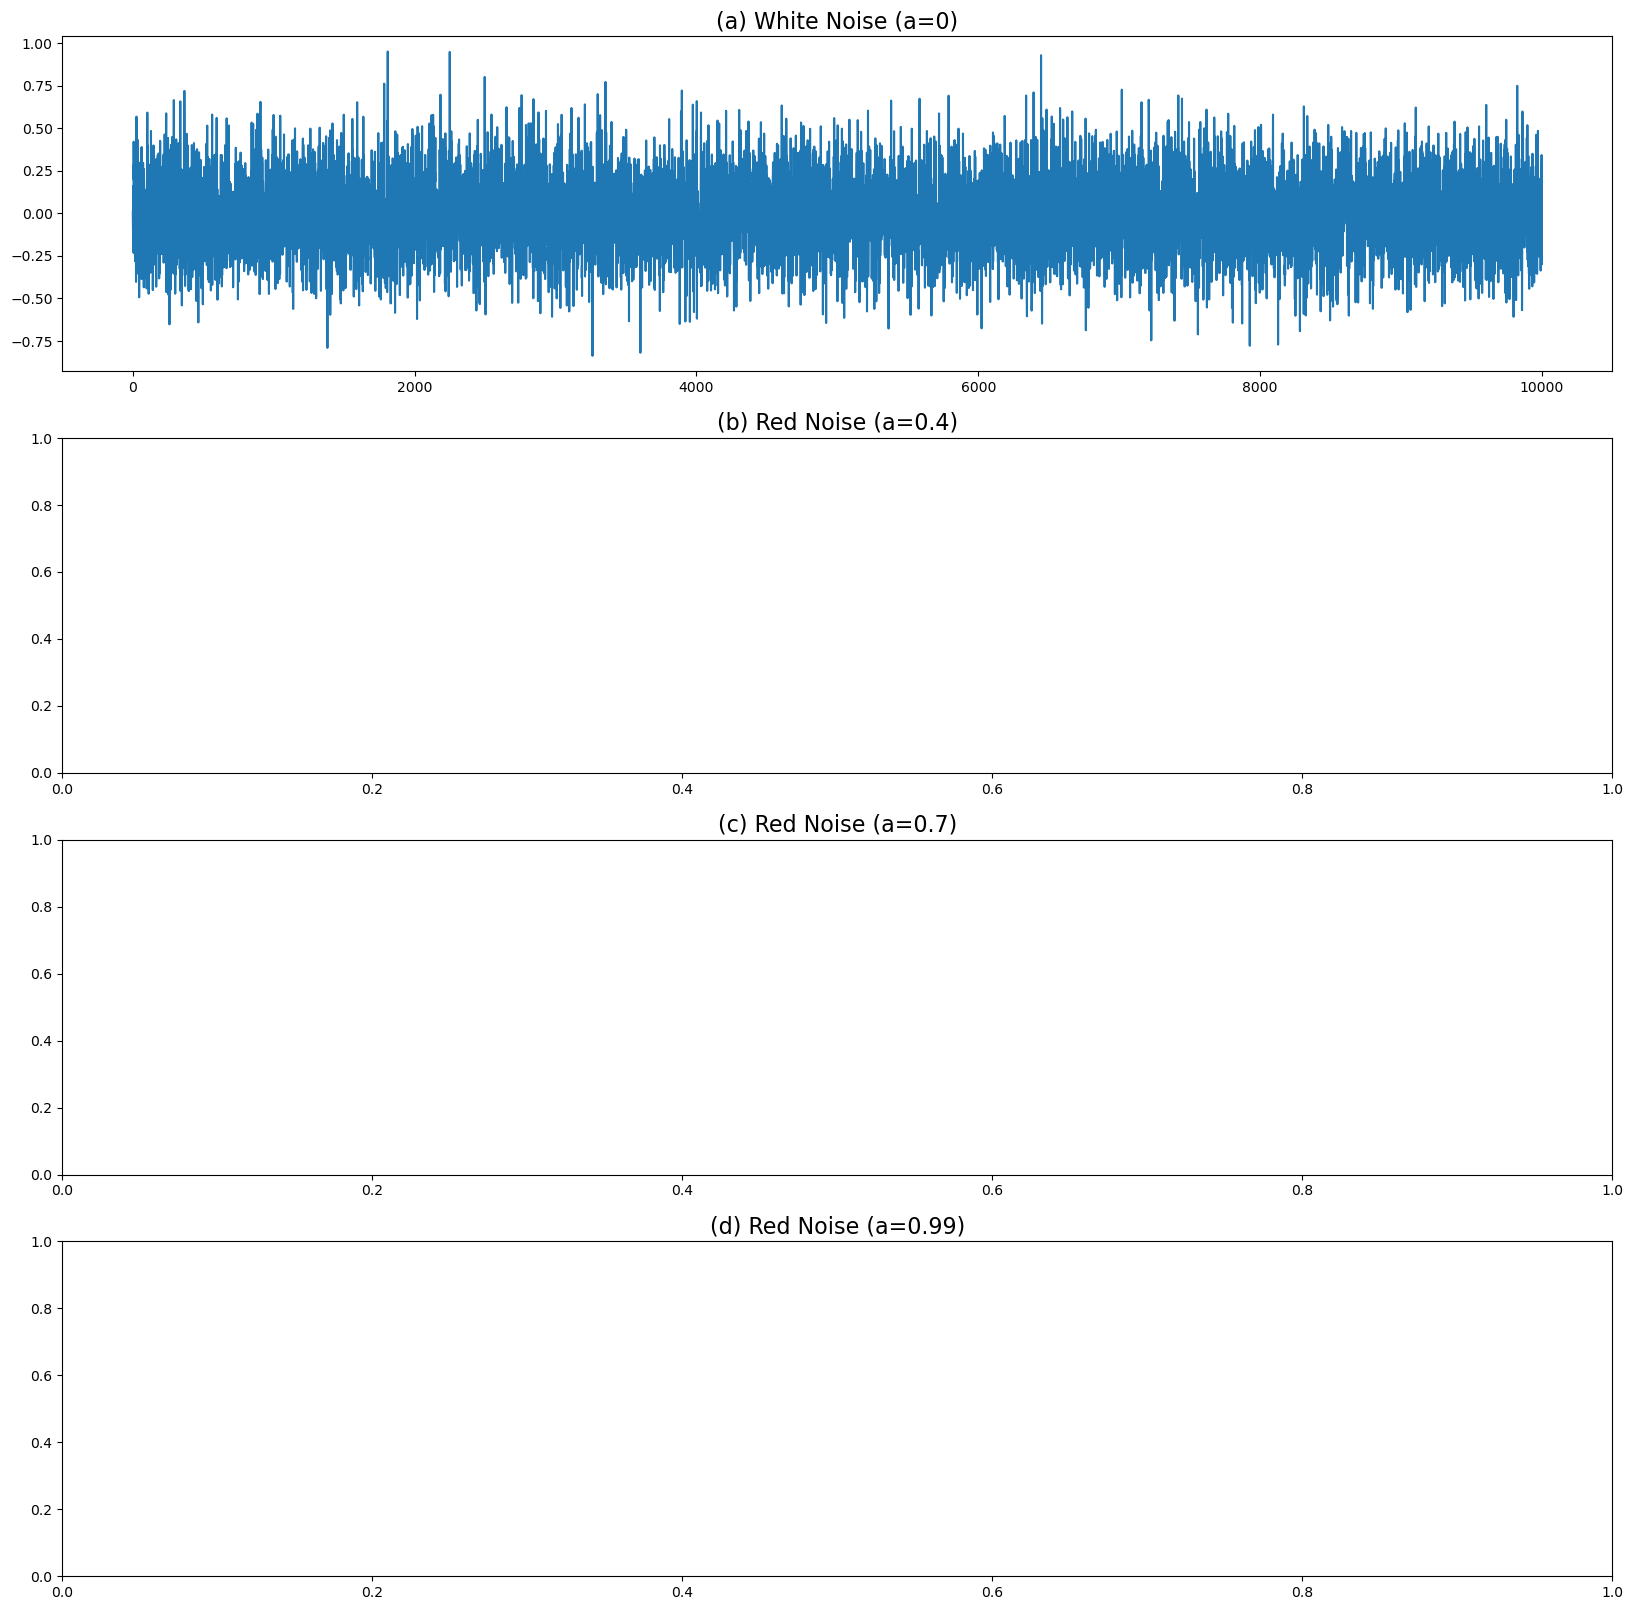

In [5]:
# only plot the first 10,000 values
plt.figure(figsize=(20,20))
plt.subplot(4,1,1)
plt.plot(x[:10000,0]) # note we are only plotting the first 10,000 time steps!
plt.title('(a) White Noise (a=0)',fontsize=16)


# finish plotting the other three time series

plt.subplot(4,1,2)
#plt.plot() # note we are only plotting the first 10,000 time steps!
plt.title('(b) Red Noise (a=0.4)',fontsize=16)

plt.subplot(4,1,3)
#plt.plot() # note we are only plotting the first 10,000 time steps!
plt.title('(c) Red Noise (a=0.7)',fontsize=16)

plt.subplot(4,1,4)
#plt.plot() # note we are only plotting the first 10,000 time steps!
plt.title('(d) Red Noise (a=0.99)',fontsize=16)


Since a red noise process is defined as one that contains autocorrelation, let's take a look at the autocorrelation functions of our four time series.

### Autocorrelation Functions

Similar to what we did in the Week 4 In-class Activity, we will compute the autocorrelation of $x$. 

Fill in the autocorrelation code below. This loop might take a bit of time to run.

In [8]:
# Compute the autocorrelation of x for each value of a using a loop

# Initialize an empty array for our autocorrelation function
acorr = np.empty((x.shape[0],x.shape[1]))


# loop over the 4 values for a
# Note: you will have to slice x in order to compute the autocorrelation as a function of time for each value of a
# Uncomment and fill in the lines below. 

#for i in range(4):
    #acorr[:,i] = # fill in this equation using the Week 4 In-class Activity notebook

Let's check the shape of acorr.

In [10]:
acorr.shape

(220500, 4)

Now, plot the autocorrelation function of $x$ for each value of $a$. We will loop over `acorr` to plot. Note: we are only going to plot the **positive lags.**

Simply run the cell below.

Text(0.5,1,'Autocorrelation Functions')

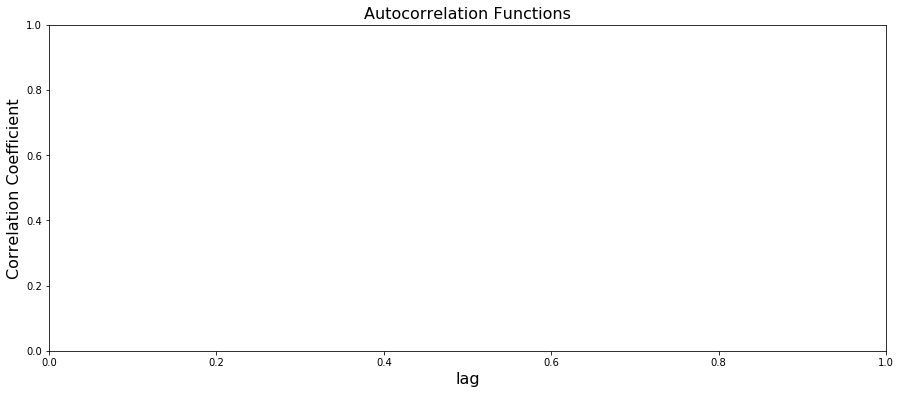

In [85]:
# Let's plot these autocorrelation functions starting from lag zero to lag 100 (just positive lags).

plt.figure(figsize=(15,6))

# We can loop over a to plot the three autocorrelation functions on the same plot 
    # with corresponding legend labels

for i in range(4):
    plt.plot(acorr[int(x.shape[0]/2):int(x.shape[0]/2)+100,i],label = 'a = ' + str(auto_vec[i]))
plt.xlabel('lag',fontsize=16)
plt.ylabel('Correlation Coefficient',fontsize=16)
plt.title('Autocorrelation Functions',fontsize=16)
plt.legend(fontsize=16)
#plt.savefig()

### Lag-1 Autocorrelation

What is the lag-1 autocorrelation of these functions?

In [8]:
# To get the lag-1 autocorrelation for acorr,
#  we find the middle index of the time dimension of acorr (the zero lag) and then add 1 to get acorr at lag +1
# Note that acorr is 2-dimensional!

a0_lag1 = acorr[int(x.shape[0]/2)+1,0]
#a1_lag1 = 
#a2_lag1 = 
#a3_lag1 = 

#print(np.round(a0_lag1,2),np.round(a1_lag1,2),np.round(a2_lag1,2),np.round(a3_lag1,2))

Do these values look familiar? What does this tell us about the meaning of $a$? We will discuss this at length in lecture.

### Audio Files

You are all probably familiar with the sound of white noise, but what about red noise? Let's save these time series as audio files and see how they sound. This is just for fun. Don't worry about the details of the code. Just run the cell and you should find four `.wav` files in your working directory. Listen to them. Do you detect an audible difference between them?

In [9]:
import math, wave, array

#Define a few parameters to audio file (don't worry about this part)
sampleRate = 44100 # of samples per second (standard)
numChan = 2 # of channels (1: mono, 2: stereo)
dataSize = 2 # 2 bytes because of using signed short integers => bit depth = 16
numSamples = x.shape[0]

#loop over a
for i in range(4):
    data = array.array('h') # signed short integer (-32768 to 32767) data; reset for each a
    #loop over t
    for j in range(numSamples):
        sample = 32767 * x[j,i]
        data.append(int(sample)) #convert to integer
    f = wave.open('Noise_a' + str(i)+ '.wav', 'w') #save file
    f.setparams((numChan, dataSize, sampleRate, numSamples, "NONE", "Uncompressed"))
    f.writeframes(data.tobytes())
    f.close()